# Modeling, Segmentation & Evaluation

## Overview
This notebook focuses on building, comparing, and evaluating machine learning models for the Bank Marketing dataset. Building on the preprocessing and feature engineering steps from previous notebooks, we now develop predictive models to estimate the likelihood of a client subscribing to a term deposit.

In addition to a traditional global modeling approach, this notebook explores a segmentation-based strategy using clusters derived earlier. By comparing a single global model against cluster-specific models, we aim to understand whether segment-level specialization leads to improved predictive performance and better business outcomes.



## Objectives
- Compare multiple candidate model architectures using the training and validation sets  
- Select a primary modeling approach based on validation performance  
- Train a global model using all available data and evaluate performance across clusters  
- Train segment-specific models for each cluster and compare against the global model  
- Perform hyperparameter tuning for both global and segment-specific models using validation data  
- Train final models using selected hyperparameters  
- Apply probability calibration to improve predicted probabilities  
<!-- - Conduct cost-sensitive analysis using calibrated probabilities and different decision thresholds  
- Evaluate final models on a held-out test set, including overall and cluster-level performance   -->



## Dataset Description
The modeling process uses the preprocessed dataset generated in the previous notebook, which includes engineered features such as categorical encodings, binary indicators, and interaction terms. Additionally, each observation is assigned to a cluster derived from unsupervised learning, enabling both global and segment-specific modeling approaches.

The data is split into three subsets:

- **Training set**: used to fit models  
- **Validation set**: used for model selection, hyperparameter tuning, and calibration  
- **Test set**: held out for final unbiased evaluation  

The target variable represents whether a client subscribed to a term deposit.



## Key Considerations
- **Model comparison**: Different model architectures are evaluated to identify the most suitable approach for the problem  
- **Segmentation strategy**: Cluster-based segmentation allows us to investigate heterogeneity in client behavior and model performance  
- **Fairness and consistency**: Performance is evaluated across clusters to detect potential disparities  
- **Overfitting prevention**: Validation data is strictly used for model selection and hyperparameter tuning  
- **Probability calibration**: Raw model probabilities may be poorly calibrated, which can negatively impact decision-making  
<!-- - **Business alignment**: Model evaluation incorporates cost-sensitive analysis, considering trade-offs between false positives (e.g., unnecessary calls) and false negatives (missed opportunities)  
- **Final evaluation integrity**: The test set remains untouched until the final evaluation step   -->



## Outcome
By the end of this notebook, we will have:
- Selected and trained a primary global model  
- Developed segment-specific models tailored to different client clusters  
- Tuned and calibrated all models for improved predictive reliability  
- Compared global and segmented approaches from both predictive and business perspectives  
- Identified optimal decision thresholds based on expected cost  
<!-- - Produced a final evaluation on the test set, including overall performance, cluster-level insights, and cost-based metrics   -->

In [1]:
import pandas as pd
import lightgbm as lgb
import optuna
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import ParameterGrid
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score

from utils.utils import (
    load_dataset,
    evaluate_model,
    evaluate_from_probs,
    plot_cluster_pr_curves,
)

RANDOM_STATE = 705

/Users/tonantzinrealrojas/miniforge3/envs/nlp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# quarto preview 03_training.ipynb --to pdf
# quarto render 03_training.ipynb
# black 03_training.ipynb

## 1. Global architecture selection

In this section, we evaluate a set of candidate model architectures to determine which will be used in the subsequent comparison between a global model (trained on all observations) and segment-specific models (trained per cluster).

We begin by training and assessing five baseline architectures using their default configurations:

1. Logistic Regression  
2. Random Forest  
3. XGBoost  
4. LightGBM  
5. CatBoost  

The goal is to identify a strong primary model that balances predictive performance and generalization before proceeding to more advanced analysis.

In [7]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# from sklearn.metrics import (
#     average_precision_score,
#     f1_score,
#     precision_score,
#     recall_score,
# )

from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

Because the outcome variable is highly imbalanced, we apply class weighting across all models to penalize misclassification of subscribers more heavily than non‑subscribers. For tree‑based models, this is implemented via the ratio of negative to positive samples, while linear and ensemble baselines use built‑in balanced class weights. This approach preserves the original data distribution and produces probability estimates suitable for downstream calibration and cost‑based decision analysis.

In [8]:
X_train_, y_train = load_dataset("02", "train")
X_validation_, y_validation = load_dataset("02", "validation")


train
X shape: (28934, 60)
y shape: (28934,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0



validation
X shape: (7234, 60)
y shape: (7234,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0


In [9]:
cluster_feat = "cluster"

X_train = X_train_.copy()
X_train = X_train.drop(columns=cluster_feat)
print("\nTrain set: ", X_train.shape)
display(X_train.head(3))

X_validation = X_validation_.copy()
X_validation = X_validation.drop(columns=cluster_feat).copy()
print("\nValidation set: ", X_validation.shape)
display(X_validation.head(3))


Train set:  (28934, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0



Validation set:  (7234, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [10]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

### i. Logistic Regression

In [11]:
log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

log_reg.fit(X_train, y_train)
log_reg_metrics = evaluate_model(log_reg, X_validation, y_validation)

### ii. Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)

rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_validation, y_validation)

### iii. XGBoost

In [13]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
)

xgb.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb, X_validation, y_validation)

### iv. LightGBM

In [14]:
lgbm = lgb.LGBMClassifier(
    objective="binary", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE
)

lgbm.fit(X_train, y_train)
lgbm_metrics = evaluate_model(lgbm, X_validation, y_validation)

[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116990 -> initscore=-2.021244
[LightGBM] [Info] Start training from score -2.021244


### v. CatBoost

In [15]:
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC",
    class_weights=[1, scale_pos_weight],
    verbose=0,
    random_state=RANDOM_STATE,
)

cat.fit(X_train, y_train)
cat_metrics = evaluate_model(cat, X_validation, y_validation)

### Results comparison

In [16]:
results = pd.DataFrame.from_dict(
    {
        "Logistic Regression": log_reg_metrics,
        "Random Forest": rf_metrics,
        "XGBoost": xgb_metrics,
        "LightGBM": lgbm_metrics,
        "CatBoost": cat_metrics,
    },
    orient="index",
)

results.sort_values(by="AUC_PR", ascending=False)

,AUC_PR,F1,Precision,Recall
LightGBM,0.445832,0.459201,0.362826,0.625296
CatBoost,0.442484,0.459831,0.368159,0.612293
Logistic Regression,0.411748,0.395126,0.287325,0.632388
XGBoost,0.407729,0.434281,0.347795,0.578014
Random Forest,0.313136,0.275808,0.413712,0.206856


On the validation set, LightGBM and CatBoost exhibit very similar performance, with nearly identical F1 scores and only a marginal difference in AUC‑PR (0.446 for LightGBM versus 0.442 for CatBoost). Both models clearly outperform the other architectures and appear well suited to handling the strong class imbalance present in the data.

LightGBM was selected as the primary model architecture because it achieves the highest AUC‑PR overall, indicating slightly better ranking of likely subscribers, while maintaining strong recall and competitive precision. Given the minimal performance gap, this choice is pragmatic rather than definitive; CatBoost remains a strong alternative and could be expected to perform similarly in downstream analysis. **LightGBM** is therefore used for the remainder of the project to provide a consistent baseline for both global and segment‑specific modeling.

## 2. Global model

Following the architecture selection, we now develop a fully optimized Global Model. This model serves as the primary benchmark for the project, trained on the full training dataset, containing observations from all clusters, to capture broad customer patterns. To manage the significant class imbalance (~11.7% success rate), we implement an analytical class-weighting strategy (scale_pos_weight) that penalizes errors on the minority class more heavily, ensuring the model prioritizes potential subscribers over the majority of non-subscribers.

Once we decided to work with LightGBM, we'll train the global model which will the observations from all clusters.

In [ ]:
X_train_, y_train = load_dataset("02", "train")
X_validation_, y_validation = load_dataset("02", "validation")


train
X shape: (28934, 60)
y shape: (28934,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0



validation
X shape: (7234, 60)
y shape: (7234,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0


In [ ]:
cluster_feat = "cluster"

X_train = X_train_.copy()
X_train = X_train.drop(columns=cluster_feat)
print("\nTrain set: ", X_train.shape)
display(X_train.head(3))

X_validation = X_validation_.copy()
X_validation = X_validation.drop(columns=cluster_feat).copy()
print("\nValidation set: ", X_validation.shape)
display(X_validation.head(3))


Train set:  (28934, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0



Validation set:  (7234, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [19]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 7.55


### 1. Hyperparameter Optimization via Optuna

We employ Bayesian Optimization using the Optuna framework to fine-tune the LightGBM hyperparameters. Unlike a standard grid search, this approach efficiently explores the parameter space to maximize the Area Under the Precision-Recall Curve (AUC-PR). This specific metric is chosen to ensure high model reliability and ranking performance within the minority positive class, which is essential for effective telemarketing targeting.

In [20]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "aucpr",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        # hyperparameters to tune
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_validation)[:, 1]
    aucpr = average_precision_score(y_validation, y_val_prob)

    return aucpr

In [21]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC-PR:", study.best_value)
print("Best parameters:", study.best_params)

best_params = study.best_params

[I 2026-04-11 22:39:25,864] A new study created in memory with name: no-name-a7d0f6a2-f999-450c-a217-c06396bf1f6f
Best trial: 0. Best value: 0.447814:   3%|▎         | 1/30 [00:02<01:07,  2.31s/it]

[I 2026-04-11 22:39:28,181] Trial 0 finished with value: 0.4478144657018903 and parameters: {'num_leaves': 69, 'max_depth': 11, 'learning_rate': 0.02936235669131735, 'n_estimators': 229, 'min_child_samples': 43}. Best is trial 0 with value: 0.4478144657018903.


Best trial: 0. Best value: 0.447814:   7%|▋         | 2/30 [00:02<00:33,  1.21s/it]

[I 2026-04-11 22:39:28,609] Trial 1 finished with value: 0.4445655332491211 and parameters: {'num_leaves': 46, 'max_depth': 2, 'learning_rate': 0.09847053773726296, 'n_estimators': 485, 'min_child_samples': 166}. Best is trial 0 with value: 0.4478144657018903.


Best trial: 0. Best value: 0.447814:  10%|█         | 3/30 [00:11<02:05,  4.63s/it]

[I 2026-04-11 22:39:37,320] Trial 2 finished with value: 0.4391926050529471 and parameters: {'num_leaves': 113, 'max_depth': -1, 'learning_rate': 0.01600332791287721, 'n_estimators': 394, 'min_child_samples': 187}. Best is trial 0 with value: 0.4478144657018903.


Best trial: 3. Best value: 0.456969:  13%|█▎        | 4/30 [00:11<01:17,  2.96s/it]

[I 2026-04-11 22:39:37,730] Trial 3 finished with value: 0.45696934844549475 and parameters: {'num_leaves': 42, 'max_depth': 3, 'learning_rate': 0.11099741955878846, 'n_estimators': 377, 'min_child_samples': 53}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  17%|█▋        | 5/30 [00:13<01:04,  2.56s/it]

[I 2026-04-11 22:39:39,581] Trial 4 finished with value: 0.44954968330392475 and parameters: {'num_leaves': 102, 'max_depth': 6, 'learning_rate': 0.04694331296216599, 'n_estimators': 562, 'min_child_samples': 62}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  20%|██        | 6/30 [00:14<00:44,  1.87s/it]

[I 2026-04-11 22:39:40,116] Trial 5 finished with value: 0.44350602721399596 and parameters: {'num_leaves': 16, 'max_depth': 8, 'learning_rate': 0.026935864753422092, 'n_estimators': 231, 'min_child_samples': 117}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  23%|██▎       | 7/30 [00:14<00:33,  1.47s/it]

[I 2026-04-11 22:39:40,764] Trial 6 finished with value: 0.44963846110177214 and parameters: {'num_leaves': 38, 'max_depth': 5, 'learning_rate': 0.027760893692519207, 'n_estimators': 269, 'min_child_samples': 60}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  27%|██▋       | 8/30 [00:18<00:49,  2.27s/it]

[I 2026-04-11 22:39:44,732] Trial 7 finished with value: 0.4313467669736031 and parameters: {'num_leaves': 108, 'max_depth': 10, 'learning_rate': 0.042649822680430736, 'n_estimators': 400, 'min_child_samples': 77}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  30%|███       | 9/30 [00:21<00:52,  2.50s/it]

[I 2026-04-11 22:39:47,741] Trial 8 finished with value: 0.43094627551942083 and parameters: {'num_leaves': 86, 'max_depth': 8, 'learning_rate': 0.052641463335253824, 'n_estimators': 557, 'min_child_samples': 146}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  33%|███▎      | 10/30 [00:22<00:40,  2.02s/it]

[I 2026-04-11 22:39:48,682] Trial 9 finished with value: 0.4526226413460322 and parameters: {'num_leaves': 81, 'max_depth': 4, 'learning_rate': 0.04495685504597684, 'n_estimators': 511, 'min_child_samples': 86}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  37%|███▋      | 11/30 [00:25<00:39,  2.08s/it]

[I 2026-04-11 22:39:50,899] Trial 10 finished with value: 0.3871406869432618 and parameters: {'num_leaves': 54, 'max_depth': 0, 'learning_rate': 0.17347861796110758, 'n_estimators': 334, 'min_child_samples': 22}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  40%|████      | 12/30 [00:25<00:28,  1.60s/it]

[I 2026-04-11 22:39:51,392] Trial 11 finished with value: 0.4564347071532654 and parameters: {'num_leaves': 75, 'max_depth': 3, 'learning_rate': 0.10025005252193218, 'n_estimators': 465, 'min_child_samples': 106}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  43%|████▎     | 13/30 [00:25<00:20,  1.22s/it]

[I 2026-04-11 22:39:51,746] Trial 12 finished with value: 0.4440400281233293 and parameters: {'num_leaves': 25, 'max_depth': 2, 'learning_rate': 0.11649356413264811, 'n_estimators': 471, 'min_child_samples': 129}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  47%|████▋     | 14/30 [00:26<00:14,  1.07it/s]

[I 2026-04-11 22:39:52,019] Trial 13 finished with value: 0.4435291437650471 and parameters: {'num_leaves': 62, 'max_depth': 2, 'learning_rate': 0.08778991929992971, 'n_estimators': 330, 'min_child_samples': 97}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  53%|█████▎    | 16/30 [00:27<00:09,  1.50it/s]

[I 2026-04-11 22:39:52,748] Trial 14 finished with value: 0.43706673116171496 and parameters: {'num_leaves': 90, 'max_depth': 4, 'learning_rate': 0.18119080610972205, 'n_estimators': 438, 'min_child_samples': 25}. Best is trial 3 with value: 0.45696934844549475.
[I 2026-04-11 22:39:52,942] Trial 15 finished with value: 0.40910326269498287 and parameters: {'num_leaves': 125, 'max_depth': 1, 'learning_rate': 0.07650709275816304, 'n_estimators': 343, 'min_child_samples': 106}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 3. Best value: 0.456969:  57%|█████▋    | 17/30 [00:28<00:11,  1.12it/s]

[I 2026-04-11 22:39:54,352] Trial 16 finished with value: 0.41873884512182197 and parameters: {'num_leaves': 34, 'max_depth': 7, 'learning_rate': 0.1336711852534865, 'n_estimators': 429, 'min_child_samples': 129}. Best is trial 3 with value: 0.45696934844549475.


Best trial: 17. Best value: 0.458737:  60%|██████    | 18/30 [00:29<00:09,  1.25it/s]

[I 2026-04-11 22:39:54,935] Trial 17 finished with value: 0.45873686834678906 and parameters: {'num_leaves': 56, 'max_depth': 4, 'learning_rate': 0.0667133655535366, 'n_estimators': 363, 'min_child_samples': 51}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  63%|██████▎   | 19/30 [00:29<00:08,  1.29it/s]

[I 2026-04-11 22:39:55,651] Trial 18 finished with value: 0.45708157305068425 and parameters: {'num_leaves': 57, 'max_depth': 5, 'learning_rate': 0.0681061793936107, 'n_estimators': 303, 'min_child_samples': 48}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  67%|██████▋   | 20/30 [00:30<00:08,  1.20it/s]

[I 2026-04-11 22:39:56,628] Trial 19 finished with value: 0.4504615038099045 and parameters: {'num_leaves': 55, 'max_depth': 6, 'learning_rate': 0.06531152498431429, 'n_estimators': 295, 'min_child_samples': 38}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  70%|███████   | 21/30 [00:32<00:08,  1.01it/s]

[I 2026-04-11 22:39:57,981] Trial 20 finished with value: 0.42780850601559517 and parameters: {'num_leaves': 61, 'max_depth': 9, 'learning_rate': 0.012156642772965338, 'n_estimators': 200, 'min_child_samples': 69}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  73%|███████▎  | 22/30 [00:32<00:06,  1.15it/s]

[I 2026-04-11 22:39:58,578] Trial 21 finished with value: 0.45658472013673357 and parameters: {'num_leaves': 46, 'max_depth': 4, 'learning_rate': 0.06587374813471407, 'n_estimators': 371, 'min_child_samples': 43}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  77%|███████▋  | 23/30 [00:33<00:05,  1.23it/s]

[I 2026-04-11 22:39:59,243] Trial 22 finished with value: 0.4454243851992407 and parameters: {'num_leaves': 39, 'max_depth': 5, 'learning_rate': 0.13260167522373814, 'n_estimators': 289, 'min_child_samples': 53}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  80%|████████  | 24/30 [00:33<00:04,  1.44it/s]

[I 2026-04-11 22:39:59,665] Trial 23 finished with value: 0.44965349113864017 and parameters: {'num_leaves': 68, 'max_depth': 3, 'learning_rate': 0.06317858046422, 'n_estimators': 366, 'min_child_samples': 86}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  83%|████████▎ | 25/30 [00:35<00:04,  1.10it/s]

[I 2026-04-11 22:40:01,076] Trial 24 finished with value: 0.45204708320422404 and parameters: {'num_leaves': 50, 'max_depth': 7, 'learning_rate': 0.0337068366758624, 'n_estimators': 304, 'min_child_samples': 34}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  87%|████████▋ | 26/30 [00:35<00:03,  1.30it/s]

[I 2026-04-11 22:40:01,512] Trial 25 finished with value: 0.4559581277073126 and parameters: {'num_leaves': 24, 'max_depth': 3, 'learning_rate': 0.07867703551324827, 'n_estimators': 412, 'min_child_samples': 52}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  90%|█████████ | 27/30 [00:35<00:01,  1.67it/s]

[I 2026-04-11 22:40:01,716] Trial 26 finished with value: 0.3926110860738095 and parameters: {'num_leaves': 31, 'max_depth': 1, 'learning_rate': 0.020283897902147824, 'n_estimators': 365, 'min_child_samples': 72}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  93%|█████████▎| 28/30 [00:36<00:01,  1.58it/s]

[I 2026-04-11 22:40:02,424] Trial 27 finished with value: 0.4451601359776289 and parameters: {'num_leaves': 62, 'max_depth': 5, 'learning_rate': 0.1525350520099038, 'n_estimators': 318, 'min_child_samples': 91}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737:  97%|█████████▋| 29/30 [00:37<00:00,  1.28it/s]

[I 2026-04-11 22:40:03,549] Trial 28 finished with value: 0.44293438467538027 and parameters: {'num_leaves': 43, 'max_depth': 7, 'learning_rate': 0.05623930095276844, 'n_estimators': 263, 'min_child_samples': 29}. Best is trial 17 with value: 0.45873686834678906.


Best trial: 17. Best value: 0.458737: 100%|██████████| 30/30 [00:39<00:00,  1.32s/it]

[I 2026-04-11 22:40:05,461] Trial 29 finished with value: 0.4487213187391542 and parameters: {'num_leaves': 72, 'max_depth': 12, 'learning_rate': 0.035146034273336624, 'n_estimators': 252, 'min_child_samples': 50}. Best is trial 17 with value: 0.45873686834678906.
Best AUC-PR: 0.45873686834678906
Best parameters: {'num_leaves': 56, 'max_depth': 4, 'learning_rate': 0.0667133655535366, 'n_estimators': 363, 'min_child_samples': 51}


We train the final global base model with the best parameters

In [22]:
global_model = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

global_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,56
,max_depth,4
,learning_rate,0.0667133655535366
,n_estimators,363
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,51


### 2. Probability Calibration

Machine learning models, particularly those using class-weighting, often produce "scores" rather than true probabilities. We apply Isotonic Regression to calibrate these outputs, aligning the model’s predicted likelihoods with the actual observed subscription rates. Well-calibrated probabilities are a prerequisite for our upcoming Business Cost Framework, where we will calculate expected ROI based on specific call costs and subscription values.

In [23]:
# raw probabilities on validation
val_probs_raw = global_model.predict_proba(X_validation)[:, 1]

# isotonic regression calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_probs_raw, y_validation)

# calibrated probabilities
val_probs_calibrated = calibrator.transform(val_probs_raw)

In [24]:
global_validation_metrics = evaluate_from_probs(y_validation, val_probs_calibrated)

print("Global model (validation, calibrated):")
print(global_validation_metrics)

Global model (validation, calibrated):
{'AUC_PR': 0.44694232107218884, 'F1': 0.31654676258992803, 'Precision': 0.6616541353383458, 'Recall': 0.20803782505910165}


### 3. Baseline Performance across Customer Segments

To evaluate the "one-size-fits-all" approach, we project the Global Model’s performance onto our four distinct customer clusters. This diagnostic step identifies where the global patterns are robust and where they fail to capture localized nuances.

In [25]:
cluster_results = {}

for c in sorted(X_validation_[cluster_feat].unique()):
    idx = X_validation_[cluster_feat] == c

    cluster_results[f"cluster_{c}"] = evaluate_from_probs(
        y_validation.loc[idx], val_probs_calibrated[idx]
    )

cluster_results_df = pd.DataFrame(cluster_results).T
cluster_results_df

,AUC_PR,F1,Precision,Recall
cluster_0,0.573545,0.444444,0.769231,0.312500
cluster_1,0.292097,0.177340,0.562500,0.105263
cluster_2,0.373361,0.260504,0.574074,0.168478
cluster_3,0.501478,0.334165,0.656863,0.224080


In [26]:
model_dir = Path("models")

model_name = "global"

# save base model
joblib.dump(global_model, model_dir / f"{model_name}_model.joblib")

# save calibrator
joblib.dump(calibrator, model_dir / f"{model_name}_calibrator.joblib")

# save metadata
metadata = {
    "best_params": best_params,
    "scale_pos_weight": scale_pos_weight,
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, model_dir / f"{model_name}_metadata.joblib")

['models/global_metadata.joblib']

## 3. Cluster 0 model

In [ ]:
cluster_id = 0
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)


train | cluster 0
X shape: (5043, 59)
y shape: (5043,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0



validation | cluster 0
X shape: (1271, 59)
y shape: (1271,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [28]:
# 2. Calculate the specific scale_pos_weight for Cluster 0
# Segment-specific weighting is essential as subscription rates vary by cluster
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"Cluster {cluster_id} - Training Shape: {X_train.shape}")
print(f"Cluster {cluster_id} - Scale Pos Weight: {scale_pos_weight:.2f}")

Cluster 0 - Training Shape: (5043, 59)
Cluster 0 - Scale Pos Weight: 6.14


### 3.1. Hyperparameter Optimization via Optuna

In [29]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "aucpr",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        # hyperparameters to tune
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_validation)[:, 1]
    aucpr = average_precision_score(y_validation, y_val_prob)

    return aucpr

In [30]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC-PR:", study.best_value)
print("Best parameters:", study.best_params)

best_params = study.best_params

[I 2026-04-11 22:40:06,370] A new study created in memory with name: no-name-b351166e-8b64-4358-93e2-007ada53965d
Best trial: 0. Best value: 0.531066:   3%|▎         | 1/30 [00:02<01:09,  2.39s/it]

[I 2026-04-11 22:40:08,763] Trial 0 finished with value: 0.5310661472319013 and parameters: {'num_leaves': 121, 'max_depth': 9, 'learning_rate': 0.012575568624929524, 'n_estimators': 483, 'min_child_samples': 31}. Best is trial 0 with value: 0.5310661472319013.


Best trial: 0. Best value: 0.531066:   7%|▋         | 2/30 [00:02<00:36,  1.30s/it]

[I 2026-04-11 22:40:09,291] Trial 1 finished with value: 0.5244108585551055 and parameters: {'num_leaves': 75, 'max_depth': 5, 'learning_rate': 0.030751198716313904, 'n_estimators': 411, 'min_child_samples': 141}. Best is trial 0 with value: 0.5310661472319013.


Best trial: 2. Best value: 0.538923:  10%|█         | 3/30 [00:03<00:29,  1.08s/it]

[I 2026-04-11 22:40:10,117] Trial 2 finished with value: 0.5389225910710985 and parameters: {'num_leaves': 118, 'max_depth': 10, 'learning_rate': 0.04346249123556202, 'n_estimators': 264, 'min_child_samples': 85}. Best is trial 2 with value: 0.5389225910710985.


Best trial: 3. Best value: 0.547976:  13%|█▎        | 4/30 [00:03<00:19,  1.35it/s]

[I 2026-04-11 22:40:10,334] Trial 3 finished with value: 0.5479760727337629 and parameters: {'num_leaves': 76, 'max_depth': 2, 'learning_rate': 0.1852727789147141, 'n_estimators': 448, 'min_child_samples': 133}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  17%|█▋        | 5/30 [00:05<00:21,  1.14it/s]

[I 2026-04-11 22:40:11,450] Trial 4 finished with value: 0.5353698136940971 and parameters: {'num_leaves': 40, 'max_depth': -1, 'learning_rate': 0.010797614566439385, 'n_estimators': 253, 'min_child_samples': 125}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  20%|██        | 6/30 [00:06<00:22,  1.09it/s]

[I 2026-04-11 22:40:12,452] Trial 5 finished with value: 0.5322610168288402 and parameters: {'num_leaves': 96, 'max_depth': 7, 'learning_rate': 0.01142823333592328, 'n_estimators': 211, 'min_child_samples': 77}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  23%|██▎       | 7/30 [00:10<00:43,  1.91s/it]

[I 2026-04-11 22:40:16,389] Trial 6 finished with value: 0.5236354925663569 and parameters: {'num_leaves': 79, 'max_depth': -1, 'learning_rate': 0.04085870153679321, 'n_estimators': 544, 'min_child_samples': 94}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  27%|██▋       | 8/30 [00:11<00:38,  1.73s/it]

[I 2026-04-11 22:40:17,750] Trial 7 finished with value: 0.5298355297600893 and parameters: {'num_leaves': 33, 'max_depth': 0, 'learning_rate': 0.15434296724047836, 'n_estimators': 312, 'min_child_samples': 173}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  30%|███       | 9/30 [00:12<00:32,  1.54s/it]

[I 2026-04-11 22:40:18,854] Trial 8 finished with value: 0.5457747905264096 and parameters: {'num_leaves': 114, 'max_depth': 10, 'learning_rate': 0.023466634573975735, 'n_estimators': 258, 'min_child_samples': 92}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  33%|███▎      | 10/30 [00:13<00:28,  1.43s/it]

[I 2026-04-11 22:40:20,047] Trial 9 finished with value: 0.5399970524933088 and parameters: {'num_leaves': 76, 'max_depth': 0, 'learning_rate': 0.032900703766422325, 'n_estimators': 437, 'min_child_samples': 192}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 3. Best value: 0.547976:  37%|███▋      | 11/30 [00:14<00:22,  1.21s/it]

[I 2026-04-11 22:40:20,749] Trial 10 finished with value: 0.520270351459665 and parameters: {'num_leaves': 48, 'max_depth': 4, 'learning_rate': 0.19661236120762624, 'n_estimators': 585, 'min_child_samples': 156}. Best is trial 3 with value: 0.5479760727337629.


Best trial: 11. Best value: 0.549778:  40%|████      | 12/30 [00:14<00:16,  1.09it/s]

[I 2026-04-11 22:40:21,015] Trial 11 finished with value: 0.5497779357150551 and parameters: {'num_leaves': 97, 'max_depth': 3, 'learning_rate': 0.12574149490345382, 'n_estimators': 358, 'min_child_samples': 51}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  47%|████▋     | 14/30 [00:15<00:08,  1.82it/s]

[I 2026-04-11 22:40:21,258] Trial 12 finished with value: 0.5289717912241562 and parameters: {'num_leaves': 96, 'max_depth': 3, 'learning_rate': 0.08601785864184892, 'n_estimators': 343, 'min_child_samples': 40}. Best is trial 11 with value: 0.5497779357150551.
[I 2026-04-11 22:40:21,424] Trial 13 finished with value: 0.545340839809516 and parameters: {'num_leaves': 62, 'max_depth': 2, 'learning_rate': 0.09919453313818126, 'n_estimators': 368, 'min_child_samples': 54}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  50%|█████     | 15/30 [00:15<00:06,  2.24it/s]

[I 2026-04-11 22:40:21,635] Trial 14 finished with value: 0.5420670727842102 and parameters: {'num_leaves': 96, 'max_depth': 2, 'learning_rate': 0.08212535488023417, 'n_estimators': 469, 'min_child_samples': 116}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  57%|█████▋    | 17/30 [00:16<00:06,  1.95it/s]

[I 2026-04-11 22:40:22,786] Trial 15 finished with value: 0.47701856479372573 and parameters: {'num_leaves': 64, 'max_depth': 7, 'learning_rate': 0.1373904225268912, 'n_estimators': 510, 'min_child_samples': 67}. Best is trial 11 with value: 0.5497779357150551.
[I 2026-04-11 22:40:22,962] Trial 16 finished with value: 0.5478407356502513 and parameters: {'num_leaves': 20, 'max_depth': 2, 'learning_rate': 0.06356290137634743, 'n_estimators': 390, 'min_child_samples': 131}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  60%|██████    | 18/30 [00:17<00:07,  1.71it/s]

[I 2026-04-11 22:40:23,716] Trial 17 finished with value: 0.45847090222522724 and parameters: {'num_leaves': 105, 'max_depth': 6, 'learning_rate': 0.19871205183613916, 'n_estimators': 328, 'min_child_samples': 23}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  63%|██████▎   | 19/30 [00:18<00:08,  1.24it/s]

[I 2026-04-11 22:40:25,037] Trial 18 finished with value: 0.49618050785877743 and parameters: {'num_leaves': 84, 'max_depth': 12, 'learning_rate': 0.12110322183524362, 'n_estimators': 454, 'min_child_samples': 107}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  70%|███████   | 21/30 [00:19<00:04,  1.91it/s]

[I 2026-04-11 22:40:25,432] Trial 19 finished with value: 0.5285135455534031 and parameters: {'num_leaves': 59, 'max_depth': 4, 'learning_rate': 0.06341654184178844, 'n_estimators': 416, 'min_child_samples': 156}. Best is trial 11 with value: 0.5497779357150551.
[I 2026-04-11 22:40:25,583] Trial 20 finished with value: 0.528544291153175 and parameters: {'num_leaves': 87, 'max_depth': 1, 'learning_rate': 0.11581744065731311, 'n_estimators': 517, 'min_child_samples': 52}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  73%|███████▎  | 22/30 [00:19<00:03,  2.37it/s]

[I 2026-04-11 22:40:25,767] Trial 21 finished with value: 0.5466138100921406 and parameters: {'num_leaves': 17, 'max_depth': 2, 'learning_rate': 0.0674274479913036, 'n_estimators': 370, 'min_child_samples': 130}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  77%|███████▋  | 23/30 [00:19<00:02,  2.56it/s]

[I 2026-04-11 22:40:26,083] Trial 22 finished with value: 0.5270059445125919 and parameters: {'num_leaves': 18, 'max_depth': 3, 'learning_rate': 0.05801006598105524, 'n_estimators': 372, 'min_child_samples': 145}. Best is trial 11 with value: 0.5497779357150551.
[I 2026-04-11 22:40:26,179] Trial 23 finished with value: 0.5201204665035678 and parameters: {'num_leaves': 49, 'max_depth': 1, 'learning_rate': 0.15567880646910914, 'n_estimators': 305, 'min_child_samples': 108}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  83%|████████▎ | 25/30 [00:20<00:01,  3.16it/s]

[I 2026-04-11 22:40:26,544] Trial 24 finished with value: 0.5370912503476131 and parameters: {'num_leaves': 68, 'max_depth': 4, 'learning_rate': 0.09455094462111, 'n_estimators': 399, 'min_child_samples': 171}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  87%|████████▋ | 26/30 [00:20<00:01,  3.28it/s]

[I 2026-04-11 22:40:26,814] Trial 25 finished with value: 0.5453907561562835 and parameters: {'num_leaves': 107, 'max_depth': 3, 'learning_rate': 0.16329677115215857, 'n_estimators': 395, 'min_child_samples': 129}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  93%|█████████▎| 28/30 [00:21<00:00,  3.17it/s]

[I 2026-04-11 22:40:27,403] Trial 26 finished with value: 0.5411352756934713 and parameters: {'num_leaves': 27, 'max_depth': 5, 'learning_rate': 0.05124211417984218, 'n_estimators': 437, 'min_child_samples': 107}. Best is trial 11 with value: 0.5497779357150551.
[I 2026-04-11 22:40:27,547] Trial 27 finished with value: 0.5328586176555753 and parameters: {'num_leaves': 89, 'max_depth': 1, 'learning_rate': 0.0751868135897225, 'n_estimators': 356, 'min_child_samples': 175}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778:  97%|█████████▋| 29/30 [00:21<00:00,  2.78it/s]

[I 2026-04-11 22:40:28,021] Trial 28 finished with value: 0.5321511606368267 and parameters: {'num_leaves': 52, 'max_depth': 6, 'learning_rate': 0.017111793318140042, 'n_estimators': 304, 'min_child_samples': 142}. Best is trial 11 with value: 0.5497779357150551.


Best trial: 11. Best value: 0.549778: 100%|██████████| 30/30 [00:21<00:00,  1.37it/s]

[I 2026-04-11 22:40:28,244] Trial 29 finished with value: 0.5456495419258414 and parameters: {'num_leaves': 107, 'max_depth': 2, 'learning_rate': 0.11495507680609166, 'n_estimators': 487, 'min_child_samples': 64}. Best is trial 11 with value: 0.5497779357150551.
Best AUC-PR: 0.5497779357150551
Best parameters: {'num_leaves': 97, 'max_depth': 3, 'learning_rate': 0.12574149490345382, 'n_estimators': 358, 'min_child_samples': 51}


In [31]:
model = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,97
,max_depth,3
,learning_rate,0.12574149490345382
,n_estimators,358
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,51


### 3.2. Probability Calibration

In [32]:
# raw probabilities on validation
val_probs_raw = model.predict_proba(X_validation)[:, 1]

# isotonic regression calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_probs_raw, y_validation)

# calibrated probabilities
val_probs_calibrated = calibrator.transform(val_probs_raw)

In [33]:
c0_validation_metrics = evaluate_from_probs(y_validation, val_probs_calibrated)

print(f"Cluster {cluster_id} model (validation, calibrated):")
print(c0_validation_metrics)

Cluster 0 model (validation, calibrated):
{'AUC_PR': 0.5456038645178486, 'F1': 0.4460431654676259, 'Precision': 0.7209302325581395, 'Recall': 0.3229166666666667}


We save the model

In [34]:
model_dir = Path("models")

model_name = f"c{cluster_id}"

# save base model
joblib.dump(model, model_dir / f"{model_name}_model.joblib")

# save calibrator
joblib.dump(calibrator, model_dir / f"{model_name}_calibrator.joblib")

# save metadata
metadata = {
    "best_params": best_params,
    "scale_pos_weight": scale_pos_weight,
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, model_dir / f"{model_name}_metadata.joblib")

['models/c0_metadata.joblib']

## 4. Cluster 1 model

In [ ]:
cluster_id = 1
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)


train | cluster 1
X shape: (8847, 59)
y shape: (8847,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



validation | cluster 1
X shape: (2266, 59)
y shape: (2266,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0



test | cluster 1
X shape: (2769, 59)
y shape: (2769,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# 2. Calculate the specific scale_pos_weight for Cluster 1
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"Cluster {cluster_id} - Training Shape: {X_train.shape}")
print(f"Cluster {cluster_id} - Scale Pos Weight: {scale_pos_weight:.2f}")

Cluster 1 - Training Shape: (8847, 59)
Cluster 1 - Scale Pos Weight: 11.34


### 4.1. Hyperparameter Optimization via Optuna


In [ ]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "aucpr",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_validation)[:, 1]
    aucpr = average_precision_score(y_validation, y_val_prob)
    return aucpr

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC-PR:", study.best_value)
print("Best parameters:", study.best_params)

best_params = study.best_params

[I 2026-04-11 22:40:29,205] A new study created in memory with name: no-name-8fc3d20f-c078-4490-a2a2-45f069462384
Best trial: 0. Best value: 0.257394:   3%|▎         | 1/30 [00:00<00:21,  1.32it/s]

[I 2026-04-11 22:40:29,968] Trial 0 finished with value: 0.25739362028779494 and parameters: {'num_leaves': 118, 'max_depth': 2, 'learning_rate': 0.16372067430794407, 'n_estimators': 531, 'min_child_samples': 115}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:   7%|▋         | 2/30 [00:03<00:51,  1.85s/it]

[I 2026-04-11 22:40:32,585] Trial 1 finished with value: 0.222551034181087 and parameters: {'num_leaves': 83, 'max_depth': 9, 'learning_rate': 0.14392701821421375, 'n_estimators': 475, 'min_child_samples': 44}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:  10%|█         | 3/30 [00:06<01:04,  2.39s/it]

[I 2026-04-11 22:40:35,615] Trial 2 finished with value: 0.22669006416987508 and parameters: {'num_leaves': 86, 'max_depth': 0, 'learning_rate': 0.12629202247623603, 'n_estimators': 542, 'min_child_samples': 185}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:  13%|█▎        | 4/30 [00:08<00:58,  2.24s/it]

[I 2026-04-11 22:40:37,635] Trial 3 finished with value: 0.21055585442185534 and parameters: {'num_leaves': 110, 'max_depth': 9, 'learning_rate': 0.13651534630494913, 'n_estimators': 278, 'min_child_samples': 36}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:  17%|█▋        | 5/30 [00:08<00:39,  1.57s/it]

[I 2026-04-11 22:40:38,024] Trial 4 finished with value: 0.25489154773760886 and parameters: {'num_leaves': 87, 'max_depth': 2, 'learning_rate': 0.15906681114175172, 'n_estimators': 580, 'min_child_samples': 92}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:  20%|██        | 6/30 [00:09<00:28,  1.19s/it]

[I 2026-04-11 22:40:38,475] Trial 5 finished with value: 0.22376589989646134 and parameters: {'num_leaves': 39, 'max_depth': 1, 'learning_rate': 0.026685097414523972, 'n_estimators': 541, 'min_child_samples': 138}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 0. Best value: 0.257394:  23%|██▎       | 7/30 [00:10<00:27,  1.19s/it]

[I 2026-04-11 22:40:39,673] Trial 6 finished with value: 0.24891885276705658 and parameters: {'num_leaves': 53, 'max_depth': 10, 'learning_rate': 0.1773164638522203, 'n_estimators': 257, 'min_child_samples': 174}. Best is trial 0 with value: 0.25739362028779494.


Best trial: 7. Best value: 0.283768:  27%|██▋       | 8/30 [00:11<00:25,  1.14s/it]

[I 2026-04-11 22:40:40,709] Trial 7 finished with value: 0.2837675880425302 and parameters: {'num_leaves': 61, 'max_depth': 10, 'learning_rate': 0.05352170002108291, 'n_estimators': 257, 'min_child_samples': 125}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  30%|███       | 9/30 [00:13<00:28,  1.34s/it]

[I 2026-04-11 22:40:42,482] Trial 8 finished with value: 0.23847366606496317 and parameters: {'num_leaves': 106, 'max_depth': 9, 'learning_rate': 0.08890488496447052, 'n_estimators': 395, 'min_child_samples': 35}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  33%|███▎      | 10/30 [00:16<00:39,  1.97s/it]

[I 2026-04-11 22:40:45,867] Trial 9 finished with value: 0.208112907271905 and parameters: {'num_leaves': 75, 'max_depth': 12, 'learning_rate': 0.06078877532112235, 'n_estimators': 475, 'min_child_samples': 23}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  37%|███▋      | 11/30 [00:16<00:27,  1.46s/it]

[I 2026-04-11 22:40:46,175] Trial 10 finished with value: 0.24045545064071322 and parameters: {'num_leaves': 20, 'max_depth': 5, 'learning_rate': 0.011579443432726577, 'n_estimators': 207, 'min_child_samples': 85}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  40%|████      | 12/30 [00:17<00:21,  1.19s/it]

[I 2026-04-11 22:40:46,730] Trial 11 finished with value: 0.26196511162518815 and parameters: {'num_leaves': 123, 'max_depth': 5, 'learning_rate': 0.0338006707878233, 'n_estimators': 355, 'min_child_samples': 132}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  43%|████▎     | 13/30 [00:18<00:16,  1.01it/s]

[I 2026-04-11 22:40:47,284] Trial 12 finished with value: 0.2653143124404377 and parameters: {'num_leaves': 50, 'max_depth': 5, 'learning_rate': 0.03247789904024487, 'n_estimators': 352, 'min_child_samples': 149}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  47%|████▋     | 14/30 [00:18<00:14,  1.09it/s]

[I 2026-04-11 22:40:48,024] Trial 13 finished with value: 0.26403417383486344 and parameters: {'num_leaves': 52, 'max_depth': 7, 'learning_rate': 0.0191294236119, 'n_estimators': 327, 'min_child_samples': 156}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  50%|█████     | 15/30 [00:19<00:12,  1.24it/s]

[I 2026-04-11 22:40:48,571] Trial 14 finished with value: 0.23273635907137508 and parameters: {'num_leaves': 55, 'max_depth': 6, 'learning_rate': 0.052527230896409816, 'n_estimators': 298, 'min_child_samples': 199}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  53%|█████▎    | 16/30 [00:20<00:11,  1.25it/s]

[I 2026-04-11 22:40:49,364] Trial 15 finished with value: 0.27633647953123847 and parameters: {'num_leaves': 32, 'max_depth': 12, 'learning_rate': 0.03412409455390066, 'n_estimators': 236, 'min_child_samples': 148}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  57%|█████▋    | 17/30 [00:20<00:08,  1.47it/s]

[I 2026-04-11 22:40:49,763] Trial 16 finished with value: 0.2617813552136476 and parameters: {'num_leaves': 17, 'max_depth': 12, 'learning_rate': 0.07328870697634876, 'n_estimators': 200, 'min_child_samples': 73}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  60%|██████    | 18/30 [00:21<00:08,  1.42it/s]

[I 2026-04-11 22:40:50,521] Trial 17 finished with value: 0.2577897075211459 and parameters: {'num_leaves': 29, 'max_depth': 11, 'learning_rate': 0.021170321722787037, 'n_estimators': 244, 'min_child_samples': 116}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  63%|██████▎   | 19/30 [00:22<00:08,  1.29it/s]

[I 2026-04-11 22:40:51,453] Trial 18 finished with value: 0.2664669389986381 and parameters: {'num_leaves': 65, 'max_depth': 7, 'learning_rate': 0.042029457893291496, 'n_estimators': 416, 'min_child_samples': 167}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  67%|██████▋   | 20/30 [00:23<00:07,  1.28it/s]

[I 2026-04-11 22:40:52,260] Trial 19 finished with value: 0.2608809190292961 and parameters: {'num_leaves': 37, 'max_depth': 11, 'learning_rate': 0.09337395451823849, 'n_estimators': 228, 'min_child_samples': 127}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  70%|███████   | 21/30 [00:24<00:07,  1.16it/s]

[I 2026-04-11 22:40:53,316] Trial 20 finished with value: 0.2567628792879916 and parameters: {'num_leaves': 69, 'max_depth': 8, 'learning_rate': 0.013701654336895039, 'n_estimators': 301, 'min_child_samples': 70}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  73%|███████▎  | 22/30 [00:25<00:07,  1.11it/s]

[I 2026-04-11 22:40:54,292] Trial 21 finished with value: 0.26195063916483935 and parameters: {'num_leaves': 64, 'max_depth': 7, 'learning_rate': 0.041901782336494116, 'n_estimators': 439, 'min_child_samples': 163}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  77%|███████▋  | 23/30 [00:26<00:06,  1.01it/s]

[I 2026-04-11 22:40:55,499] Trial 22 finished with value: 0.2625636434368555 and parameters: {'num_leaves': 39, 'max_depth': 10, 'learning_rate': 0.042018262858688815, 'n_estimators': 400, 'min_child_samples': 173}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  80%|████████  | 24/30 [00:27<00:06,  1.15s/it]

[I 2026-04-11 22:40:57,004] Trial 23 finished with value: 0.2708977859932459 and parameters: {'num_leaves': 61, 'max_depth': 12, 'learning_rate': 0.05545242306226614, 'n_estimators': 393, 'min_child_samples': 140}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  83%|████████▎ | 25/30 [00:28<00:05,  1.07s/it]

[I 2026-04-11 22:40:57,887] Trial 24 finished with value: 0.26554914176540007 and parameters: {'num_leaves': 28, 'max_depth': 12, 'learning_rate': 0.05927263146830478, 'n_estimators': 263, 'min_child_samples': 100}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  87%|████████▋ | 26/30 [00:29<00:04,  1.14s/it]

[I 2026-04-11 22:40:59,202] Trial 25 finished with value: 0.2645417005559937 and parameters: {'num_leaves': 98, 'max_depth': 11, 'learning_rate': 0.07832741100782833, 'n_estimators': 354, 'min_child_samples': 142}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  90%|█████████ | 27/30 [00:31<00:03,  1.26s/it]

[I 2026-04-11 22:41:00,723] Trial 26 finished with value: 0.28270172438092284 and parameters: {'num_leaves': 76, 'max_depth': 10, 'learning_rate': 0.031847768794104156, 'n_estimators': 323, 'min_child_samples': 120}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  93%|█████████▎| 28/30 [00:32<00:02,  1.18s/it]

[I 2026-04-11 22:41:01,728] Trial 27 finished with value: 0.27360415680660805 and parameters: {'num_leaves': 77, 'max_depth': 10, 'learning_rate': 0.026654523682346623, 'n_estimators': 228, 'min_child_samples': 104}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768:  97%|█████████▋| 29/30 [00:33<00:01,  1.11s/it]

[I 2026-04-11 22:41:02,684] Trial 28 finished with value: 0.26877437221327594 and parameters: {'num_leaves': 92, 'max_depth': 8, 'learning_rate': 0.018574182443674, 'n_estimators': 322, 'min_child_samples': 120}. Best is trial 7 with value: 0.2837675880425302.


Best trial: 7. Best value: 0.283768: 100%|██████████| 30/30 [00:34<00:00,  1.16s/it]

[I 2026-04-11 22:41:03,873] Trial 29 finished with value: 0.2649295466527023 and parameters: {'num_leaves': 77, 'max_depth': 10, 'learning_rate': 0.033856464800083565, 'n_estimators': 287, 'min_child_samples': 112}. Best is trial 7 with value: 0.2837675880425302.
Best AUC-PR: 0.2837675880425302
Best parameters: {'num_leaves': 61, 'max_depth': 10, 'learning_rate': 0.05352170002108291, 'n_estimators': 257, 'min_child_samples': 125}


In [ ]:
model = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,61
,max_depth,10
,learning_rate,0.05352170002108291
,n_estimators,257
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,125


### 4.2. Probability Calibration


In [ ]:
# raw probabilities on validation
val_probs_raw = model.predict_proba(X_validation)[:, 1]

# isotonic regression calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_probs_raw, y_validation)

# calibrated probabilities
val_probs_calibrated = calibrator.transform(val_probs_raw)

In [ ]:
c1_validation_metrics = evaluate_from_probs(y_validation, val_probs_calibrated)

print(f"Cluster {cluster_id} model (validation, calibrated):")
print(c1_validation_metrics)

Cluster 1 model (validation, calibrated):
{'AUC_PR': 0.2786453337479804, 'F1': 0.19900497512437812, 'Precision': 0.6666666666666666, 'Recall': 0.11695906432748537}


In [ ]:
# save the model and calibrator for cluster 1
model_dir = Path("models")
model_name = f"c{cluster_id}"

# save model
joblib.dump(model, model_dir / f"{model_name}_model.joblib")

# save calibrator
joblib.dump(calibrator, model_dir / f"{model_name}_calibrator.joblib")

# save metadata
metadata = {
    "best_params": best_params,
    "scale_pos_weight": scale_pos_weight,
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, model_dir / f"{model_name}_metadata.joblib")

['models/c1_metadata.joblib']

## 5. Cluster 2 model

In [ ]:
cluster_id = 2
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)


train | cluster 2
X shape: (7058, 59)
y shape: (7058,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
11,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



validation | cluster 2
X shape: (1720, 59)
y shape: (1720,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



test | cluster 2
X shape: (2201, 59)
y shape: (2201,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [44]:
# 2. Calculate the specific scale_pos_weight for Cluster 2
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"Cluster {cluster_id} - Training Shape: {X_train.shape}")
print(f"Cluster {cluster_id} - Scale Pos Weight: {scale_pos_weight:.2f}")

Cluster 2 - Training Shape: (7058, 59)
Cluster 2 - Scale Pos Weight: 7.96


### 5.1. Hyperparameter Optimization via Optuna

In [45]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "aucpr",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_validation)[:, 1]
    aucpr = average_precision_score(y_validation, y_val_prob)
    return aucpr

In [46]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC-PR:", study.best_value)
print("Best parameters:", study.best_params)

best_params = study.best_params

[I 2026-04-11 22:41:05,206] A new study created in memory with name: no-name-601ff287-4a3a-4541-9ae9-da7d6cdc99ea
Best trial: 0. Best value: 0.34768:   3%|▎         | 1/30 [00:00<00:14,  2.01it/s]

[I 2026-04-11 22:41:05,710] Trial 0 finished with value: 0.3476797615973629 and parameters: {'num_leaves': 26, 'max_depth': 3, 'learning_rate': 0.023426828465021598, 'n_estimators': 484, 'min_child_samples': 39}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:   7%|▋         | 2/30 [00:01<00:18,  1.50it/s]

[I 2026-04-11 22:41:06,492] Trial 1 finished with value: 0.28922831072947786 and parameters: {'num_leaves': 104, 'max_depth': 4, 'learning_rate': 0.13294833949968798, 'n_estimators': 494, 'min_child_samples': 67}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  10%|█         | 3/30 [00:02<00:28,  1.06s/it]

[I 2026-04-11 22:41:08,026] Trial 2 finished with value: 0.26943942994365316 and parameters: {'num_leaves': 39, 'max_depth': 10, 'learning_rate': 0.10614017054507825, 'n_estimators': 568, 'min_child_samples': 174}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  13%|█▎        | 4/30 [00:03<00:26,  1.01s/it]

[I 2026-04-11 22:41:08,958] Trial 3 finished with value: 0.3141035173716834 and parameters: {'num_leaves': 64, 'max_depth': 9, 'learning_rate': 0.04437999990378162, 'n_estimators': 258, 'min_child_samples': 80}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  17%|█▋        | 5/30 [00:04<00:20,  1.19it/s]

[I 2026-04-11 22:41:09,493] Trial 4 finished with value: 0.25798959887157535 and parameters: {'num_leaves': 74, 'max_depth': 9, 'learning_rate': 0.16954025550405605, 'n_estimators': 226, 'min_child_samples': 182}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  20%|██        | 6/30 [00:05<00:26,  1.09s/it]

[I 2026-04-11 22:41:11,057] Trial 5 finished with value: 0.331340450332198 and parameters: {'num_leaves': 58, 'max_depth': 10, 'learning_rate': 0.01772155368489328, 'n_estimators': 471, 'min_child_samples': 128}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  23%|██▎       | 7/30 [00:07<00:26,  1.17s/it]

[I 2026-04-11 22:41:12,403] Trial 6 finished with value: 0.2483694764718477 and parameters: {'num_leaves': 34, 'max_depth': 9, 'learning_rate': 0.1332311750331235, 'n_estimators': 396, 'min_child_samples': 36}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  27%|██▋       | 8/30 [00:08<00:25,  1.18s/it]

[I 2026-04-11 22:41:13,603] Trial 7 finished with value: 0.3299175430139323 and parameters: {'num_leaves': 93, 'max_depth': 6, 'learning_rate': 0.014357478192272856, 'n_estimators': 561, 'min_child_samples': 82}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  30%|███       | 9/30 [00:09<00:24,  1.19s/it]

[I 2026-04-11 22:41:14,815] Trial 8 finished with value: 0.30248672724165826 and parameters: {'num_leaves': 108, 'max_depth': -1, 'learning_rate': 0.01442468671601579, 'n_estimators': 429, 'min_child_samples': 196}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 0. Best value: 0.34768:  33%|███▎      | 10/30 [00:10<00:19,  1.05it/s]

[I 2026-04-11 22:41:15,242] Trial 9 finished with value: 0.3310454469969295 and parameters: {'num_leaves': 41, 'max_depth': 4, 'learning_rate': 0.02318765680436136, 'n_estimators': 393, 'min_child_samples': 73}. Best is trial 0 with value: 0.3476797615973629.


Best trial: 10. Best value: 0.351341:  37%|███▋      | 11/30 [00:10<00:16,  1.16it/s]

[I 2026-04-11 22:41:15,887] Trial 10 finished with value: 0.3513412549800843 and parameters: {'num_leaves': 16, 'max_depth': 0, 'learning_rate': 0.03758084472118996, 'n_estimators': 322, 'min_child_samples': 36}. Best is trial 10 with value: 0.3513412549800843.


Best trial: 11. Best value: 0.352604:  40%|████      | 12/30 [00:11<00:14,  1.28it/s]

[I 2026-04-11 22:41:16,490] Trial 11 finished with value: 0.352603720145778 and parameters: {'num_leaves': 16, 'max_depth': 0, 'learning_rate': 0.03795908973750222, 'n_estimators': 316, 'min_child_samples': 20}. Best is trial 11 with value: 0.352603720145778.


Best trial: 11. Best value: 0.352604:  47%|████▋     | 14/30 [00:12<00:09,  1.75it/s]

[I 2026-04-11 22:41:17,240] Trial 12 finished with value: 0.33861628334109173 and parameters: {'num_leaves': 21, 'max_depth': -1, 'learning_rate': 0.04759320505880708, 'n_estimators': 310, 'min_child_samples': 20}. Best is trial 11 with value: 0.352603720145778.
[I 2026-04-11 22:41:17,349] Trial 13 finished with value: 0.32444320157968787 and parameters: {'num_leaves': 17, 'max_depth': 1, 'learning_rate': 0.04789148055021402, 'n_estimators': 333, 'min_child_samples': 129}. Best is trial 11 with value: 0.352603720145778.


Best trial: 11. Best value: 0.352604:  53%|█████▎    | 16/30 [00:12<00:04,  2.97it/s]

[I 2026-04-11 22:41:17,456] Trial 14 finished with value: 0.33860895838261035 and parameters: {'num_leaves': 128, 'max_depth': 1, 'learning_rate': 0.07251617419200306, 'n_estimators': 305, 'min_child_samples': 49}. Best is trial 11 with value: 0.352603720145778.
[I 2026-04-11 22:41:17,572] Trial 15 finished with value: 0.33562140427528553 and parameters: {'num_leaves': 47, 'max_depth': 1, 'learning_rate': 0.031673334581132806, 'n_estimators': 351, 'min_child_samples': 20}. Best is trial 11 with value: 0.352603720145778.


Best trial: 17. Best value: 0.356615:  60%|██████    | 18/30 [00:12<00:03,  3.19it/s]

[I 2026-04-11 22:41:18,020] Trial 16 finished with value: 0.3423461840192134 and parameters: {'num_leaves': 16, 'max_depth': 6, 'learning_rate': 0.03361760572675305, 'n_estimators': 264, 'min_child_samples': 99}. Best is trial 11 with value: 0.352603720145778.
[I 2026-04-11 22:41:18,202] Trial 17 finished with value: 0.35661459689099806 and parameters: {'num_leaves': 54, 'max_depth': 2, 'learning_rate': 0.07657553475959958, 'n_estimators': 368, 'min_child_samples': 55}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  63%|██████▎   | 19/30 [00:13<00:03,  3.29it/s]

[I 2026-04-11 22:41:18,484] Trial 18 finished with value: 0.3348647011485238 and parameters: {'num_leaves': 79, 'max_depth': 3, 'learning_rate': 0.07224919447399623, 'n_estimators': 372, 'min_child_samples': 58}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  67%|██████▋   | 20/30 [00:14<00:04,  2.12it/s]

[I 2026-04-11 22:41:19,346] Trial 19 finished with value: 0.3094107415647866 and parameters: {'num_leaves': 57, 'max_depth': 12, 'learning_rate': 0.07044446875070014, 'n_estimators': 215, 'min_child_samples': 112}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  70%|███████   | 21/30 [00:14<00:03,  2.53it/s]

[I 2026-04-11 22:41:19,560] Trial 20 finished with value: 0.3496228125815707 and parameters: {'num_leaves': 82, 'max_depth': 2, 'learning_rate': 0.08836901072449359, 'n_estimators': 444, 'min_child_samples': 147}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  73%|███████▎  | 22/30 [00:15<00:04,  1.77it/s]

[I 2026-04-11 22:41:20,526] Trial 21 finished with value: 0.3420327262460883 and parameters: {'num_leaves': 29, 'max_depth': 0, 'learning_rate': 0.038311261728970786, 'n_estimators': 285, 'min_child_samples': 40}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  77%|███████▋  | 23/30 [00:17<00:07,  1.10s/it]

[I 2026-04-11 22:41:22,878] Trial 22 finished with value: 0.29291223037129743 and parameters: {'num_leaves': 50, 'max_depth': -1, 'learning_rate': 0.05528153059102717, 'n_estimators': 341, 'min_child_samples': 28}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  83%|████████▎ | 25/30 [00:19<00:04,  1.16it/s]

[I 2026-04-11 22:41:24,190] Trial 23 finished with value: 0.3270462949728678 and parameters: {'num_leaves': 31, 'max_depth': 0, 'learning_rate': 0.021312795424069875, 'n_estimators': 372, 'min_child_samples': 54}. Best is trial 17 with value: 0.35661459689099806.
[I 2026-04-11 22:41:24,351] Trial 24 finished with value: 0.335376748958731 and parameters: {'num_leaves': 46, 'max_depth': 2, 'learning_rate': 0.030351171634775072, 'n_estimators': 312, 'min_child_samples': 89}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  87%|████████▋ | 26/30 [00:19<00:03,  1.33it/s]

[I 2026-04-11 22:41:24,841] Trial 25 finished with value: 0.3294888621670784 and parameters: {'num_leaves': 24, 'max_depth': 5, 'learning_rate': 0.010671079368829297, 'n_estimators': 248, 'min_child_samples': 60}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  93%|█████████▎| 28/30 [00:22<00:02,  1.02s/it]

[I 2026-04-11 22:41:27,670] Trial 26 finished with value: 0.2637064590606037 and parameters: {'num_leaves': 64, 'max_depth': 0, 'learning_rate': 0.0562203597480423, 'n_estimators': 418, 'min_child_samples': 39}. Best is trial 17 with value: 0.35661459689099806.
[I 2026-04-11 22:41:27,850] Trial 27 finished with value: 0.33901656209095055 and parameters: {'num_leaves': 36, 'max_depth': 2, 'learning_rate': 0.027165563316225168, 'n_estimators': 358, 'min_child_samples': 49}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615:  97%|█████████▋| 29/30 [00:24<00:01,  1.24s/it]

[I 2026-04-11 22:41:29,603] Trial 28 finished with value: 0.28717595513263094 and parameters: {'num_leaves': 87, 'max_depth': 7, 'learning_rate': 0.09541958181397721, 'n_estimators': 288, 'min_child_samples': 28}. Best is trial 17 with value: 0.35661459689099806.


Best trial: 17. Best value: 0.356615: 100%|██████████| 30/30 [00:24<00:00,  1.20it/s]

[I 2026-04-11 22:41:30,204] Trial 29 finished with value: 0.3533234986941247 and parameters: {'num_leaves': 26, 'max_depth': 3, 'learning_rate': 0.04037024348845201, 'n_estimators': 504, 'min_child_samples': 42}. Best is trial 17 with value: 0.35661459689099806.
Best AUC-PR: 0.35661459689099806
Best parameters: {'num_leaves': 54, 'max_depth': 2, 'learning_rate': 0.07657553475959958, 'n_estimators': 368, 'min_child_samples': 55}


In [47]:
model = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,54
,max_depth,2
,learning_rate,0.07657553475959958
,n_estimators,368
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,55


### 5.2. Probability Calibration

In [48]:
# raw probabilities on validation
val_probs_raw = model.predict_proba(X_validation)[:, 1]

# isotonic regression calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_probs_raw, y_validation)

# calibrated probabilities
val_probs_calibrated = calibrator.transform(val_probs_raw)

In [49]:
c2_validation_metrics = evaluate_from_probs(y_validation, val_probs_calibrated)

print(f"Cluster {cluster_id} model (validation, calibrated):")
print(c2_validation_metrics)

Cluster 2 model (validation, calibrated):
{'AUC_PR': 0.3487701483135698, 'F1': 0.26609442060085836, 'Precision': 0.6326530612244898, 'Recall': 0.16847826086956522}


In [50]:
# save the model and calibrator for cluster 2
model_dir = Path("models")
model_name = f"c{cluster_id}"

# save model
joblib.dump(model, model_dir / f"{model_name}_model.joblib")

# save calibrator
joblib.dump(calibrator, model_dir / f"{model_name}_calibrator.joblib")

# save metadata
metadata = {
    "best_params": best_params,
    "scale_pos_weight": scale_pos_weight,
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, model_dir / f"{model_name}_metadata.joblib")

['models/c2_metadata.joblib']

## 6. Cluster 3 model

In [ ]:
cluster_id = 3
X_train, y_train = load_dataset(nb="02", split="train", cluster_id=cluster_id)
X_validation, y_validation = load_dataset(
    nb="02", split="validation", cluster_id=cluster_id
)


train | cluster 3
X shape: (7986, 59)
y shape: (7986,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



validation | cluster 3
X shape: (1977, 59)
y shape: (1977,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



test | cluster 3
X shape: (2461, 59)
y shape: (2461,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [52]:
# Calculate cluster-specific scale_pos_weight
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"Cluster {cluster_id} - Training Shape: {X_train.shape}")
print(f"Cluster {cluster_id} - Scale Pos Weight: {scale_pos_weight:.2f}")

Cluster 3 - Training Shape: (7986, 59)
Cluster 3 - Scale Pos Weight: 5.80


### 6.1. Hyperparameter Optimization via Optuna


In [53]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "aucpr",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_validation)[:, 1]
    aucpr = average_precision_score(y_validation, y_val_prob)
    return aucpr

In [54]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC-PR:", study.best_value)
print("Best parameters:", study.best_params)

best_params = study.best_params

[I 2026-04-11 22:41:30,794] A new study created in memory with name: no-name-8427a1ae-77c7-48b3-9ad3-0d44f7fc4b30
Best trial: 0. Best value: 0.468725:   3%|▎         | 1/30 [00:04<01:58,  4.08s/it]

[I 2026-04-11 22:41:34,869] Trial 0 finished with value: 0.4687249958013377 and parameters: {'num_leaves': 90, 'max_depth': 12, 'learning_rate': 0.013410190944080688, 'n_estimators': 505, 'min_child_samples': 43}. Best is trial 0 with value: 0.4687249958013377.


Best trial: 1. Best value: 0.490409:   7%|▋         | 2/30 [00:04<00:57,  2.06s/it]

[I 2026-04-11 22:41:35,518] Trial 1 finished with value: 0.49040930050961085 and parameters: {'num_leaves': 86, 'max_depth': 5, 'learning_rate': 0.05181200100245093, 'n_estimators': 219, 'min_child_samples': 150}. Best is trial 1 with value: 0.49040930050961085.


Best trial: 1. Best value: 0.490409:  10%|█         | 3/30 [00:07<01:02,  2.31s/it]

[I 2026-04-11 22:41:38,131] Trial 2 finished with value: 0.43521339428702427 and parameters: {'num_leaves': 44, 'max_depth': 0, 'learning_rate': 0.15524487222252242, 'n_estimators': 298, 'min_child_samples': 83}. Best is trial 1 with value: 0.49040930050961085.


Best trial: 1. Best value: 0.490409:  13%|█▎        | 4/30 [00:07<00:41,  1.59s/it]

[I 2026-04-11 22:41:38,628] Trial 3 finished with value: 0.4835536153117025 and parameters: {'num_leaves': 70, 'max_depth': 3, 'learning_rate': 0.0825245948195073, 'n_estimators': 471, 'min_child_samples': 37}. Best is trial 1 with value: 0.49040930050961085.


Best trial: 4. Best value: 0.491037:  17%|█▋        | 5/30 [00:08<00:30,  1.23s/it]

[I 2026-04-11 22:41:39,203] Trial 4 finished with value: 0.4910372467810263 and parameters: {'num_leaves': 99, 'max_depth': 3, 'learning_rate': 0.03276533732625248, 'n_estimators': 452, 'min_child_samples': 49}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  20%|██        | 6/30 [00:09<00:29,  1.22s/it]

[I 2026-04-11 22:41:40,412] Trial 5 finished with value: 0.467713583790982 and parameters: {'num_leaves': 71, 'max_depth': 8, 'learning_rate': 0.03742304909285066, 'n_estimators': 370, 'min_child_samples': 118}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  23%|██▎       | 7/30 [00:09<00:21,  1.06it/s]

[I 2026-04-11 22:41:40,774] Trial 6 finished with value: 0.4742961561125311 and parameters: {'num_leaves': 67, 'max_depth': 3, 'learning_rate': 0.022006231913549956, 'n_estimators': 464, 'min_child_samples': 48}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  27%|██▋       | 8/30 [00:12<00:29,  1.32s/it]

[I 2026-04-11 22:41:42,913] Trial 7 finished with value: 0.4754676551581094 and parameters: {'num_leaves': 37, 'max_depth': 11, 'learning_rate': 0.012459602690930988, 'n_estimators': 510, 'min_child_samples': 91}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  30%|███       | 9/30 [00:15<00:39,  1.86s/it]

[I 2026-04-11 22:41:45,955] Trial 8 finished with value: 0.4167467387764828 and parameters: {'num_leaves': 103, 'max_depth': 0, 'learning_rate': 0.09679003547871948, 'n_estimators': 287, 'min_child_samples': 22}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  33%|███▎      | 10/30 [00:15<00:27,  1.37s/it]

[I 2026-04-11 22:41:46,233] Trial 9 finished with value: 0.4800166350535603 and parameters: {'num_leaves': 68, 'max_depth': 2, 'learning_rate': 0.04280602125796461, 'n_estimators': 580, 'min_child_samples': 72}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  37%|███▋      | 11/30 [00:16<00:23,  1.24s/it]

[I 2026-04-11 22:41:47,173] Trial 10 finished with value: 0.4690773071507495 and parameters: {'num_leaves': 126, 'max_depth': 8, 'learning_rate': 0.025730563607980997, 'n_estimators': 396, 'min_child_samples': 188}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  40%|████      | 12/30 [00:16<00:17,  1.02it/s]

[I 2026-04-11 22:41:47,567] Trial 11 finished with value: 0.48751448466078623 and parameters: {'num_leaves': 102, 'max_depth': 6, 'learning_rate': 0.06583952291813679, 'n_estimators': 204, 'min_child_samples': 149}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  43%|████▎     | 13/30 [00:17<00:13,  1.27it/s]

[I 2026-04-11 22:41:47,902] Trial 12 finished with value: 0.47092994153643525 and parameters: {'num_leaves': 126, 'max_depth': 5, 'learning_rate': 0.025173588151207977, 'n_estimators': 215, 'min_child_samples': 142}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  47%|████▋     | 14/30 [00:17<00:11,  1.38it/s]

[I 2026-04-11 22:41:48,491] Trial 13 finished with value: 0.4726364197021058 and parameters: {'num_leaves': 92, 'max_depth': 6, 'learning_rate': 0.057111816700966704, 'n_estimators': 335, 'min_child_samples': 190}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  50%|█████     | 15/30 [00:18<00:09,  1.54it/s]

[I 2026-04-11 22:41:48,962] Trial 14 finished with value: 0.47848765498245815 and parameters: {'num_leaves': 20, 'max_depth': 4, 'learning_rate': 0.13120920015816429, 'n_estimators': 435, 'min_child_samples': 153}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  53%|█████▎    | 16/30 [00:19<00:13,  1.07it/s]

[I 2026-04-11 22:41:50,555] Trial 15 finished with value: 0.4671461697397321 and parameters: {'num_leaves': 87, 'max_depth': 8, 'learning_rate': 0.03479760326964584, 'n_estimators': 595, 'min_child_samples': 117}. Best is trial 4 with value: 0.4910372467810263.
[I 2026-04-11 22:41:50,649] Trial 16 finished with value: 0.42217565866907925 and parameters: {'num_leaves': 113, 'max_depth': 1, 'learning_rate': 0.019673858010808308, 'n_estimators': 263, 'min_child_samples': 169}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  60%|██████    | 18/30 [00:20<00:07,  1.53it/s]

[I 2026-04-11 22:41:51,212] Trial 17 finished with value: 0.4785419672703098 and parameters: {'num_leaves': 50, 'max_depth': 5, 'learning_rate': 0.055400325729053124, 'n_estimators': 356, 'min_child_samples': 102}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  63%|██████▎   | 19/30 [00:22<00:12,  1.10s/it]

[I 2026-04-11 22:41:53,655] Trial 18 finished with value: 0.45097084898400547 and parameters: {'num_leaves': 82, 'max_depth': -1, 'learning_rate': 0.031401952750335485, 'n_estimators': 537, 'min_child_samples': 131}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  67%|██████▋   | 20/30 [00:24<00:12,  1.29s/it]

[I 2026-04-11 22:41:55,469] Trial 19 finished with value: 0.4152543575660367 and parameters: {'num_leaves': 108, 'max_depth': 10, 'learning_rate': 0.09645810596654276, 'n_estimators': 420, 'min_child_samples': 59}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  70%|███████   | 21/30 [00:25<00:10,  1.12s/it]

[I 2026-04-11 22:41:56,135] Trial 20 finished with value: 0.4603633825130714 and parameters: {'num_leaves': 54, 'max_depth': 7, 'learning_rate': 0.19046805201721542, 'n_estimators': 256, 'min_child_samples': 163}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 4. Best value: 0.491037:  73%|███████▎  | 22/30 [00:25<00:07,  1.08it/s]

[I 2026-04-11 22:41:56,557] Trial 21 finished with value: 0.4897292129922002 and parameters: {'num_leaves': 98, 'max_depth': 6, 'learning_rate': 0.061826707132475955, 'n_estimators': 215, 'min_child_samples': 139}. Best is trial 4 with value: 0.4910372467810263.


Best trial: 22. Best value: 0.494625:  77%|███████▋  | 23/30 [00:26<00:05,  1.32it/s]

[I 2026-04-11 22:41:56,903] Trial 22 finished with value: 0.4946246488160022 and parameters: {'num_leaves': 96, 'max_depth': 4, 'learning_rate': 0.04993468677168869, 'n_estimators': 240, 'min_child_samples': 130}. Best is trial 22 with value: 0.4946246488160022.


Best trial: 22. Best value: 0.494625:  80%|████████  | 24/30 [00:26<00:03,  1.64it/s]

[I 2026-04-11 22:41:57,151] Trial 23 finished with value: 0.49025001711560684 and parameters: {'num_leaves': 81, 'max_depth': 3, 'learning_rate': 0.04641702596346449, 'n_estimators': 324, 'min_child_samples': 123}. Best is trial 22 with value: 0.4946246488160022.


Best trial: 22. Best value: 0.494625:  87%|████████▋ | 26/30 [00:26<00:01,  2.50it/s]

[I 2026-04-11 22:41:57,420] Trial 24 finished with value: 0.47520177760012705 and parameters: {'num_leaves': 115, 'max_depth': 4, 'learning_rate': 0.01684307812482411, 'n_estimators': 246, 'min_child_samples': 98}. Best is trial 22 with value: 0.4946246488160022.
[I 2026-04-11 22:41:57,557] Trial 25 finished with value: 0.4464499112470423 and parameters: {'num_leaves': 80, 'max_depth': 2, 'learning_rate': 0.030484911931758642, 'n_estimators': 242, 'min_child_samples': 172}. Best is trial 22 with value: 0.4946246488160022.


Best trial: 22. Best value: 0.494625:  90%|█████████ | 27/30 [00:27<00:01,  2.57it/s]

[I 2026-04-11 22:41:57,920] Trial 26 finished with value: 0.4910729951274079 and parameters: {'num_leaves': 116, 'max_depth': 4, 'learning_rate': 0.04655152414980103, 'n_estimators': 302, 'min_child_samples': 74}. Best is trial 22 with value: 0.4946246488160022.


Best trial: 22. Best value: 0.494625:  97%|█████████▋| 29/30 [00:27<00:00,  3.13it/s]

[I 2026-04-11 22:41:58,265] Trial 27 finished with value: 0.4839727137582376 and parameters: {'num_leaves': 118, 'max_depth': 4, 'learning_rate': 0.07682567076168328, 'n_estimators': 297, 'min_child_samples': 68}. Best is trial 22 with value: 0.4946246488160022.
[I 2026-04-11 22:41:58,451] Trial 28 finished with value: 0.45379099631861963 and parameters: {'num_leaves': 97, 'max_depth': 2, 'learning_rate': 0.010179247171296516, 'n_estimators': 365, 'min_child_samples': 20}. Best is trial 22 with value: 0.4946246488160022.


Best trial: 22. Best value: 0.494625: 100%|██████████| 30/30 [00:27<00:00,  1.08it/s]

[I 2026-04-11 22:41:58,586] Trial 29 finished with value: 0.45150312295617123 and parameters: {'num_leaves': 108, 'max_depth': 1, 'learning_rate': 0.042776518740566497, 'n_estimators': 404, 'min_child_samples': 44}. Best is trial 22 with value: 0.4946246488160022.
Best AUC-PR: 0.4946246488160022
Best parameters: {'num_leaves': 96, 'max_depth': 4, 'learning_rate': 0.04993468677168869, 'n_estimators': 240, 'min_child_samples': 130}


In [55]:
model = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,96
,max_depth,4
,learning_rate,0.04993468677168869
,n_estimators,240
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,130


### 6.2. Probability Calibration


In [56]:
# raw probabilities on validation
val_probs_raw = model.predict_proba(X_validation)[:, 1]

# isotonic regression calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_probs_raw, y_validation)

# calibrated probabilities
val_probs_calibrated = calibrator.transform(val_probs_raw)

In [57]:
c3_validation_metrics = evaluate_from_probs(y_validation, val_probs_calibrated)

print(f"Cluster {cluster_id} model (validation, calibrated):")
print(c3_validation_metrics)

Cluster 3 model (validation, calibrated):
{'AUC_PR': 0.48541909654074455, 'F1': 0.4430379746835443, 'Precision': 0.6, 'Recall': 0.3511705685618729}


In [58]:
# save the model and calibrator for cluster 3
model_dir = Path("models")
model_name = f"c{cluster_id}"

# save model
joblib.dump(model, model_dir / f"{model_name}_model.joblib")

# save calibrator
joblib.dump(calibrator, model_dir / f"{model_name}_calibrator.joblib")

# save metadata
metadata = {
    "best_params": best_params,
    "scale_pos_weight": scale_pos_weight,
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, model_dir / f"{model_name}_metadata.joblib")

['models/c3_metadata.joblib']

## 7. Model Comparison on the Validation Set

This section provides a unified, validation‑based comparison between the calibrated global model and the calibrated cluster‑specific models. By evaluating all models on the same validation data, we assess whether segmentation improves predictive performance before any test data is used.

First we load models and validation data

In [2]:
# directory with saved models
MODEL_DIR = Path("models")

# load validation data (full, with cluster labels)
X_val_full, y_val = load_dataset("02", "validation")

cluster_col = "cluster"
# feature matrix used for prediction
X_val = X_val_full.drop(columns=[cluster_col])
X_val = X_val_full.drop(columns=[cluster_col])
print(X_val.shape)
X_val.head(3)


validation
X shape: (7234, 60)
y shape: (7234,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0


(7234, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__default,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [3]:
# load global model and calibrator
global_model = joblib.load(MODEL_DIR / "global_model.joblib")
global_calibrator = joblib.load(MODEL_DIR / "global_calibrator.joblib")
global_metadata = joblib.load(MODEL_DIR / "global_metadata.joblib")

# ensure correct feature order
X_val_global = X_val[global_metadata["features"]]

# calibrated probabilities
global_probs_raw = global_model.predict_proba(X_val_global)[:, 1]
global_probs_cal = global_calibrator.transform(global_probs_raw)

# overall global performance
rows = []

rows.append(
    {"Model": "Global", "Scope": "All", **evaluate_from_probs(y_val, global_probs_cal)}
)

We do the cluster‑level comparison: **Global vs Segment Models**

In [4]:
for cluster_id in sorted(X_val_full[cluster_col].unique()):
    idx = X_val_full[cluster_col] == cluster_id

    # ----- Global model on this cluster -----
    rows.append(
        {
            "Model": "Global",
            "Scope": f"Cluster {cluster_id}",
            **evaluate_from_probs(y_val.loc[idx], global_probs_cal[idx]),
        }
    )

    # ----- Cluster-specific model -----
    model = joblib.load(MODEL_DIR / f"c{cluster_id}_model.joblib")
    calibrator = joblib.load(MODEL_DIR / f"c{cluster_id}_calibrator.joblib")
    metadata = joblib.load(MODEL_DIR / f"c{cluster_id}_metadata.joblib")

    X_val_cluster = X_val.loc[idx, metadata["features"]]

    probs_raw = model.predict_proba(X_val_cluster)[:, 1]
    probs_cal = calibrator.transform(probs_raw)

    rows.append(
        {
            "Model": "Cluster-specific",
            "Scope": f"Cluster {cluster_id}",
            **evaluate_from_probs(y_val.loc[idx], probs_cal),
        }
    )

In [5]:
comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(by=["Scope", "Model"]).reset_index(drop=True)

,Model,Scope,AUC_PR,F1,Precision,Recall
0,Global,All,0.446942,0.316547,0.661654,0.208038
1,Cluster-specific,Cluster 0,0.545604,0.446043,0.720930,0.322917
2,Global,Cluster 0,0.573545,0.444444,0.769231,0.312500
3,Cluster-specific,Cluster 1,0.278645,0.199005,0.666667,0.116959
4,Global,Cluster 1,0.292097,0.177340,0.562500,0.105263
5,Cluster-specific,Cluster 2,0.348770,0.266094,0.632653,0.168478
6,Global,Cluster 2,0.373361,0.260504,0.574074,0.168478
7,Cluster-specific,Cluster 3,0.485419,0.443038,0.600000,0.351171
8,Global,Cluster 3,0.501478,0.334165,0.656863,0.224080


The global model achieves higher AUC-PR across all clusters, indicating better overall ranking and discrimination between positive and negative cases. In contrast, cluster-specific models often achieve higher F1 and recall within individual clusters, suggesting they better capture cluster-specific patterns and improve threshold-dependent performance. This highlights a trade-off: the global model excels at general separation, while cluster-specific models can improve detection in certain segments.

## 8. Precision–Recall Curve Analysis

In [2]:
MODEL_DIR = Path("models")

global_model = joblib.load(MODEL_DIR / "global_model.joblib")
global_calibrator = joblib.load(MODEL_DIR / "global_calibrator.joblib")
global_metadata = joblib.load(MODEL_DIR / "global_metadata.joblib")

In [3]:
# load validation data (full, with cluster labels)
X_val_full, y_val = load_dataset("02", "validation")

cluster_col = "cluster"
# X_val_full already has cluster labels
X_val = X_val_full.drop(columns=[cluster_col])

# Ensure correct feature order for global model
X_val_global = X_val[global_metadata["features"]]


validation
X shape: (7234, 60)
y shape: (7234,)

X head:


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,bin__housing,bin__loan,bin__poutcome_success,bin__contact_is_unknown,bin__poutcome_is_unknown,bin__multiple_contacts_current_campaign,bin__previous_and_many_current_contacts,bin__many_contacts_and_housing_loan,bin__both_housing_and_personal_loan,cluster
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0


In [4]:
# Raw probabilities
global_probs_raw = global_model.predict_proba(X_val_global)[:, 1]

# Calibrated probabilities
global_probs_cal = global_calibrator.transform(global_probs_raw)

In [5]:
cluster_models = {}
cluster_calibrators = {}
cluster_metadata = {}

for cluster_id in sorted(X_val_full[cluster_col].unique()):
    cluster_models[cluster_id] = joblib.load(MODEL_DIR / f"c{cluster_id}_model.joblib")
    cluster_calibrators[cluster_id] = joblib.load(
        MODEL_DIR / f"c{cluster_id}_calibrator.joblib"
    )
    cluster_metadata[cluster_id] = joblib.load(
        MODEL_DIR / f"c{cluster_id}_metadata.joblib"
    )

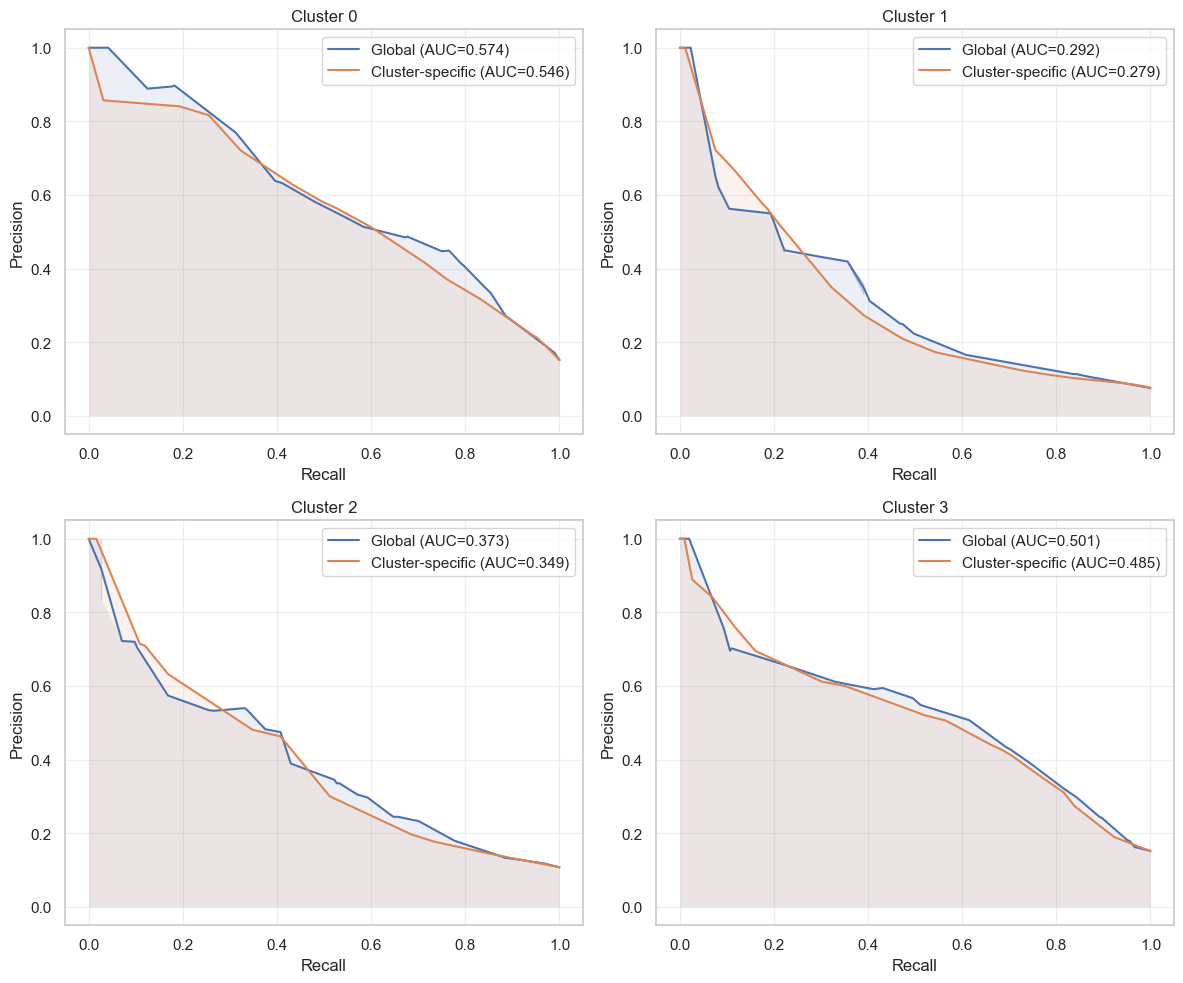

In [6]:
plot_cluster_pr_curves(
    global_probs_cal=global_probs_cal,
    y_val=y_val,
    X_val=X_val,
    cluster_models=cluster_models,
    cluster_calibrators=cluster_calibrators,
    cluster_metadata=cluster_metadata,
    X_val_full=X_val_full,
    cluster_col="cluster",
)

The precision–recall curves highlight how model performance varies across customer segments. For both the global and cluster-specific models, their curves overlap closely and none of the models dominates greatly over the other.

## 9. Business Cost Framework

To translate model predictions into actionable decisions, we define a simple cost-based framework reflecting the trade-offs in telemarketing campaigns.

The bank must decide which customers to contact under limited resources. Each contact incurs a cost (e.g., agent time, operational expenses), while successful subscriptions generate revenue. Therefore, the objective is to maximize the net benefit of the campaign rather than purely predictive performance.

We define:
- `C_call`: cost of contacting a customer
- `B_sub`: benefit from a successful subscription

This leads to the following trade-offs:
- Contacting likely subscribers → generates profit
- Contacting unlikely subscribers → wastes resources
- Not contacting likely subscribers → missed opportunity

In expectation, a customer should be contacted only if:
$$\text{expected benefit} > \text{cost of contact}$$

This condition defines the minimum probability threshold required for a contact to be profitable.

That is, when:
$$\text{predicted probability x B\_sub} > \text{C\_call}$$
This framework connects model outputs (predicted probabilities) with business decisions and highlights the importance of well-calibrated probabilities, since inaccurate probabilities would lead to systematically suboptimal contact decisions.

### Interpretation of Threshold-Tuned Results

When evaluating threshold tuning results, performance metrics reflect different aspects of this cost-benefit trade-off:

| Metric       | Interpretation |
|--------------|----------------|
| Recall       | Captures more subscribers (reduces missed opportunities) |
| Precision    | Reduces wasted calls (improves call efficiency) |
| F1           | Balances both recall and precision objectives |
| PR-AUC       | Reflects overall ranking quality, independent of threshold |

### Practical decision rule

- If campaign budget is constrained, prioritize higher precision at acceptable recall
- If growth targets dominate, prioritize higher recall subject to a minimum precision
- The selected threshold should align with operational constraints (agent capacity, call cost, and expected conversion value)

In [ ]:
# Define business parameters (can be adjusted for sensitivity analysis)
C_call = 1.0  # cost per call (normalized)
B_sub = 10.0  # benefit per successful subscription

# Break-even probability threshold (minimum probability to justify a call)
break_even_p = C_call / B_sub
print(f"Break-even probability: {break_even_p:.3f}")

Break-even probability: 0.100


## 10. Threshold Selection via Expected Cost

Threshold selection is performed exclusively on the validation set to avoid overfitting. The selected threshold will be applied unchanged to the test set in the final evaluation.

## 11. Summary of Validation‑Stage Findings